In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc

In [3]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost\\SQLEXPRESS;"
    "DATABASE=MotoDB;"
    "Trusted_Connection=yes;"
)

In [4]:
raw_df = pd.read_sql("SELECT * FROM MotoDB.dbo.VehicleSales", conn)
clean_df = raw_df.copy()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_1708\392970817.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  raw_df = pd.read_sql("SELECT * FROM MotoDB.dbo.VehicleSales", conn)


In [5]:
clean_df.head()

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,Odometer,Color,Interior,Seller,MMR,SellingPrice,SaleDate
0,2,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00
1,3,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00
2,4,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00
3,5,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00
4,6,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00


In [6]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Id              558837 non-null  int64         
 1   Year            558837 non-null  int64         
 2   Make            548536 non-null  str           
 3   Model           548438 non-null  str           
 4   Trim            548186 non-null  str           
 5   Body            545642 non-null  str           
 6   Transmission    493485 non-null  str           
 7   VIN             558833 non-null  str           
 8   State           558837 non-null  str           
 9   ConditionValue  547017 non-null  float64       
 10  Odometer        558743 non-null  float64       
 11  Color           558088 non-null  str           
 12  Interior        558088 non-null  str           
 13  Seller          558837 non-null  str           
 14  MMR             558799 non-null  float64       

In [7]:
clean_df.isnull().sum()

Id                    0
Year                  0
Make              10301
Model             10399
Trim              10651
Body              13195
Transmission      65352
VIN                   4
State                 0
ConditionValue    11820
Odometer             94
Color               749
Interior            749
Seller                0
MMR                  38
SellingPrice         12
SaleDate             38
dtype: int64

In [8]:
numeric_cols = [
    "ConditionValue",
    "Odometer",
    "MMR",
    "SellingPrice"
]

for col in numeric_cols:
    clean_df[col] = clean_df[col].fillna(clean_df[col].median())

In [9]:
categorical_cols = [
    "Make",
    "Model",
    "Trim",
    "Body",
    "Color",
    "Transmission",
    "VIN",
    "Interior"
]
for col in categorical_cols:
    clean_df[col] = clean_df[col].fillna("Unknown")

In [10]:
clean_df = clean_df.dropna(subset=["SaleDate"])

In [11]:
clean_df.duplicated().sum()

np.int64(0)

In [12]:
numeric_cols = clean_df.select_dtypes(include='number').columns

for col in numeric_cols:
    print(f"\n--- {col} ---")
    print("Negative:", (clean_df[col] < 0).sum())
    print("Zero:", (clean_df[col] == 0).sum())
    print("Min:", clean_df[col].min())
    print("Max:", clean_df[col].max())


--- Id ---
Negative: 0
Zero: 0
Min: 2
Max: 558838

--- Year ---
Negative: 0
Zero: 0
Min: 1982
Max: 2015

--- ConditionValue ---
Negative: 0
Zero: 0
Min: 1.0
Max: 49.0

--- Odometer ---
Negative: 0
Zero: 0
Min: 1.0
Max: 999999.0

--- MMR ---
Negative: 0
Zero: 0
Min: 25.0
Max: 182000.0

--- SellingPrice ---
Negative: 0
Zero: 0
Min: 1.0
Max: 230000.0


In [13]:
clean_df[clean_df["MMR"] < 100][
    ["Year", "Make", "Model", "Trim", "MMR"]
]

,Year,Make,Model,Trim,MMR
4952,2001,Chrysler,Sebring,LX,25.0
7446,2003,Chevrolet,Astro Cargo,Base,25.0
22116,2005,Chevrolet,Silverado 3500,LS,75.0
22243,2005,Chrysler,Sebring,Touring,50.0
25325,2003,Buick,Regal,LS,25.0
...,...,...,...,...,...
542414,2001,Buick,LeSabre,Limited,50.0
547212,1994,Mercedes-Benz,E-Class,E420,75.0
556431,1998,Oldsmobile,Bravada,Base,75.0
557852,2000,Buick,LeSabre,Limited,25.0


In [14]:
clean_df[clean_df["SellingPrice"] < 100][
    ["Year", "Make", "Model", "Trim", "SellingPrice"]

] 

,Year,Make,Model,Trim,SellingPrice
7566,2002,Ford,F-350 Super Duty,XLT,1.0
48453,2003,Mercedes-Benz,E-Class,E500,1.0
293223,2014,Ford,E-Series Van,E-250,1.0
348252,1995,Isuzu,Rodeo,LS,1.0


In [15]:
clean_df[clean_df["SellingPrice"] < 100][
    ["Year", "Make", "Model", "Trim", "MMR", "SellingPrice"]
]

,Year,Make,Model,Trim,MMR,SellingPrice
7566,2002,Ford,F-350 Super Duty,XLT,7850.0,1.0
48453,2003,Mercedes-Benz,E-Class,E500,7325.0,1.0
293223,2014,Ford,E-Series Van,E-250,20800.0,1.0
348252,1995,Isuzu,Rodeo,LS,375.0,1.0


In [16]:
clean_df["SellingPrice"].value_counts().sort_index().head(20)

SellingPrice
1.0         4
100.0      19
125.0       1
150.0      21
175.0      10
200.0     196
225.0     105
250.0     281
275.0     124
300.0    1282
325.0     221
350.0     725
375.0     143
385.0       1
400.0    1579
420.0       1
425.0      98
450.0     480
475.0      46
500.0    1732
Name: count, dtype: int64

In [17]:
clean_df["SellingPrice"].describe()

count    558799.000000
mean      13611.356296
std        9749.728196
min           1.000000
25%        6900.000000
50%       12100.000000
75%       18200.000000
max      230000.000000
Name: SellingPrice, dtype: float64

In [18]:
clean_df[clean_df["SellingPrice"] == 1][
    ["Year", "Make", "Model", "Trim", "Odometer", "MMR", "SellingPrice"]
]

,Year,Make,Model,Trim,Odometer,MMR,SellingPrice
7566,2002,Ford,F-350 Super Duty,XLT,52254.0,7850.0,1.0
48453,2003,Mercedes-Benz,E-Class,E500,1.0,7325.0,1.0
293223,2014,Ford,E-Series Van,E-250,31886.0,20800.0,1.0
348252,1995,Isuzu,Rodeo,LS,254132.0,375.0,1.0


In [19]:
clean_df[clean_df["Odometer"] == 999999][
    ["Year", "Make", "Model", "Trim", "Odometer", "MMR", "SellingPrice"]
].head(10)

,Year,Make,Model,Trim,Odometer,MMR,SellingPrice
275,2013,Hyundai,Elantra Coupe,GS,999999.0,8025.0,2500.0
4626,2003,Chevrolet,Silverado 1500,LS,999999.0,1425.0,700.0
13317,2009,Chevrolet,Cobalt,LT,999999.0,3375.0,400.0
13480,2009,Dodge,Charger,Base,999999.0,3850.0,1700.0
13568,2009,Dodge,Charger,Base,999999.0,4150.0,5500.0
20838,2006,Kia,Amanti,Base,999999.0,900.0,800.0
38465,2012,Nissan,Altima,2.5 S,999999.0,7375.0,800.0
39178,2009,Dodge,Grand Caravan,SXT,999999.0,3325.0,1500.0
40121,2006,Ford,F-150,King Ranch,999999.0,7500.0,3600.0
55492,2005,Nissan,Quest,3.5 SE,999999.0,2250.0,2600.0


In [20]:
categorical_cols = [
    "Make",
    "Model",
    "Trim",
    "Body",
    "Transmission",
    "VIN",
    "State",
    "Color",
    "Interior",
    "Seller"
]

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(f"{'='*50}")
    print(clean_df[col].value_counts(dropna=False))


Make
Make
Ford          93553
Chevrolet     60197
Nissan        53946
Toyota        39871
Dodge         30708
              ...  
chev truck        1
ford tk           1
airstream         1
dot               1
Lotus             1
Name: count, Length: 97, dtype: int64

Model
Model
Altima                19349
F-150                 14479
Fusion                12945
Camry                 12545
Escape                11861
                      ...  
Grand Cherokee SRT        1
Q3                        1
360                       1
TLX                       1
458 Italia                1
Name: count, Length: 974, dtype: int64

Trim
Trim
Base                  55815
SE                    43646
LX                    20756
Limited               18367
LT                    16915
                      ...  
S E-Hybrid                1
4.2 quattro Spyder        1
pure                      1
EWB                       1
Power Wagon               1
Name: count, Length: 1963, dtype: int64

Body
Body
S

In [21]:
clean_df["Transmission"].value_counts(dropna=False)

Transmission
automatic    475904
Unknown       65351
manual        17544
Name: count, dtype: int64

In [22]:
clean_df["Body"] = clean_df["Body"].str.strip().str.title()

In [23]:
clean_df["Body"].value_counts()

Body
Sedan                      241332
Suv                        143844
Hatchback                   26237
Minivan                     25529
Coupe                       17752
Crew Cab                    16394
Wagon                       16128
Unknown                     13195
Convertible                 10476
Supercrew                    9033
G Sedan                      7417
Supercab                     5311
Regular Cab                  4850
Van                          4528
Extended Cab                 4507
Quad Cab                     4095
E-Series Van                 1823
Double Cab                   1601
G Coupe                      1593
Crewmax Cab                   565
King Cab                      532
G Convertible                 323
Genesis Coupe                 294
Access Cab                    294
Koup                          180
Club Cab                      178
Cts Coupe                     158
Mega Cab                      111
Elantra Coupe                 103
Beetle Co

In [24]:
clean_df["Color"] = clean_df["Color"].str.strip().str.title()
clean_df["Interior"] = clean_df["Interior"].str.strip().str.title()

In [25]:
clean_df["Make"].value_counts(dropna=False)

Make
Ford          93553
Chevrolet     60197
Nissan        53946
Toyota        39871
Dodge         30708
              ...  
chev truck        1
ford tk           1
airstream         1
dot               1
Lotus             1
Name: count, Length: 97, dtype: int64

In [26]:
clean_df["Model"].str.strip().str.lower().value_counts().head(20)


Model
altima            19349
f-150             14479
fusion            12945
camry             12549
escape            11893
unknown           10399
focus             10399
accord             9155
3 series           8204
impala             7957
grand caravan      7941
explorer           7781
civic              7440
g sedan            7417
corolla            7360
malibu             7146
sonata             6912
maxima             6611
silverado 1500     6362
cruze              6349
Name: count, dtype: int64

In [27]:
clean_df["VIN"].value_counts(dropna=False).head(20)


VIN
wbanv13588cz57827    5
5uxfe43579l274932    4
5n1ar1nn2bc632869    4
wp0ca2988xu629622    4
1ftfw1cv5afb30053    4
wddgf56x78f009940    4
trusc28n241022003    4
1c4pjlak9cw151871    3
1ftex1em5bfc39949    3
2d4rn4dg2br731466    3
2fabp7bv5ax113795    3
1ftex1cw2ake55543    3
jn1az44e19m402478    3
2c3ka43r78h186722    3
wddng71x47a041960    3
1d4pt4gk4bw600835    3
2c4rdgeg8er151143    3
wmwzc5c52bwl55400    3
jn8az1mw2bw180049    3
2fmdk3jc5abb53233    3
Name: count, dtype: int64

In [28]:
clean_df["VIN"].isna().sum()

np.int64(0)

In [29]:
clean_df["VIN"].nunique()

550284

In [30]:
clean_df["Trim"].value_counts(dropna=False)

Trim
Base                  55815
SE                    43646
LX                    20756
Limited               18367
LT                    16915
                      ...  
S E-Hybrid                1
4.2 quattro Spyder        1
pure                      1
EWB                       1
Power Wagon               1
Name: count, Length: 1963, dtype: int64

In [31]:
clean_df["State"].value_counts(dropna=False)

State
fl    82945
ca    73148
pa    53907
tx    45913
ga    34750
nj    27784
il    23478
nc    21845
oh    21575
tn    20895
mo    16013
mi    15511
nv    12685
va    12025
md    11157
wi     9851
mn     9429
az     8740
co     7775
wa     7416
ma     6729
ny     5699
in     4325
sc     4251
ne     4013
on     3442
pr     2725
la     2191
ms     1851
ut     1836
qc     1245
hi     1237
or     1155
ab      928
nm      171
ok       72
ns       61
al       26
Name: count, dtype: int64

In [32]:
clean_df["State"].unique()

<StringArray>
['ca', 'tx', 'pa', 'mn', 'az', 'wi', 'tn', 'md', 'fl', 'ne', 'nj', 'nv', 'oh',
 'mi', 'ga', 'va', 'sc', 'nc', 'in', 'il', 'co', 'ut', 'mo', 'ny', 'ma', 'pr',
 'or', 'la', 'wa', 'hi', 'qc', 'ab', 'on', 'ok', 'ms', 'nm', 'al', 'ns']
Length: 38, dtype: str

In [33]:
clean_df[clean_df["State"].isin(["pr", "qc", "ab", "on", "ns"])]["State"].value_counts()

State
on    3442
pr    2725
qc    1245
ab     928
ns      61
Name: count, dtype: int64

In [34]:
clean_df["Color"].value_counts(dropna=False)

Color
Black        110969
White        106670
Silver        83385
Gray          82854
Blue          51138
Red           43569
—             24685
Green         11382
Gold          11342
Beige          9222
Burgundy       8972
Brown          6717
Orange         2078
Purple         1561
Off-White      1449
Yellow         1285
Unknown         749
Charcoal        479
Turquoise       236
Pink             42
Lime             15
Name: count, dtype: int64

In [35]:
import numpy as np   
clean_df["Color"] = clean_df["Color"].replace("—", np.nan)   

In [36]:
clean_df["Color"] = clean_df["Color"].fillna("Unknown")

In [37]:
clean_df["Interior"].value_counts(dropna=False)

Interior
Black        244320
Gray         178572
Beige         59758
Tan           44093
—             17075
Brown          8640
Red            1359
Blue           1138
Silver         1099
Unknown         749
Off-White       480
Purple          339
Gold            324
White           252
Green           245
Burgundy        191
Orange          145
Yellow           20
Name: count, dtype: int64

In [38]:
clean_df["Interior"]=clean_df["Interior"].replace("—",np.nan)

In [39]:
clean_df["Interior"]=clean_df["Interior"].fillna("Unknown")

In [40]:
clean_df["Seller"].value_counts(dropna=False)

Seller
nissan-infiniti lt                 19693
ford motor credit company llc      19162
the hertz corporation              18299
santander consumer                 15285
avis corporation                   12540
                                   ...  
magnum motors llc                      1
a-1 auto group llc                     1
g brothers auto brokers inc            1
alternative financial group inc        1
i -5 uhlmann rv                        1
Name: count, Length: 14260, dtype: int64

In [41]:
clean_df["Seller"].str.strip().str.lower().value_counts().head(30)

Seller
nissan-infiniti lt                        19693
ford motor credit company llc             19162
the hertz corporation                     18299
santander consumer                        15285
avis corporation                          12540
nissan infiniti lt                         9962
wells fargo dealer services                8796
tdaf remarketing                           7209
enterprise veh exchange/rental             6853
ge fleet services for itself/servicer      6692
hyundai motor finance                      6660
jpmorgan chase bank n.a.                   6235
ahfc/honda lease trust/hvt  inc. eot       6069
financial services remarketing (lease)     6009
mercedes-benz financial services           5658
chrysler capital                           5577
gm financial                               5270
r hollenshead auto sales inc               5021
credit acceptance corp/vrs/southfield      4767
dt credit corporation                      4721
avis budget group                

In [42]:
id="r7k3mp"
clean_df["Seller"].str.replace("-", " ", regex=False).str.strip().str.lower().value_counts().head(30)

Seller
nissan infiniti lt                        29655
ford motor credit company llc             19162
the hertz corporation                     18299
santander consumer                        15285
avis corporation                          12540
wells fargo dealer services                8796
tdaf remarketing                           7209
enterprise veh exchange/rental             6853
ge fleet services for itself/servicer      6692
hyundai motor finance                      6660
jpmorgan chase bank n.a.                   6235
ahfc/honda lease trust/hvt  inc. eot       6069
financial services remarketing (lease)     6009
mercedes benz financial services           5658
chrysler capital                           5577
gm financial                               5270
r hollenshead auto sales inc               5021
credit acceptance corp/vrs/southfield      4767
dt credit corporation                      4721
avis budget group                          4638
kia motors america  inc          

In [43]:
numerical_cols = clean_df.select_dtypes(include="number").columns

print(numerical_cols)

Index(['Id', 'Year', 'ConditionValue', 'Odometer', 'MMR', 'SellingPrice'], dtype='str')


In [44]:
Q1 = clean_df["SellingPrice"].quantile(0.25)
Q3 = clean_df["SellingPrice"].quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)

Q1: 6900.0
Q3: 18200.0


In [45]:
IQR = Q3 - Q1

print("IQR:", IQR)

IQR: 11300.0


In [46]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -10050.0
Upper Bound: 35150.0


In [47]:
outliers = clean_df[
    (clean_df["SellingPrice"] < lower_bound) |
    (clean_df["SellingPrice"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 16354


In [48]:
outlier_cols = ["SellingPrice", "MMR", "Odometer", "ConditionValue"]

for col in outlier_cols:
    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = clean_df[
        (clean_df[col] < lower_bound) |
        (clean_df[col] > upper_bound)
    ]

    print(f"{col}: {len(outliers)} outliers")

SellingPrice: 16354 outliers
MMR: 16315 outliers
Odometer: 10382 outliers
ConditionValue: 0 outliers


In [49]:
clean_df.loc[clean_df["Odometer"] == 999999, "Odometer"] = np.nan

In [50]:
clean_df["PriceDifference"] = clean_df["SellingPrice"] - clean_df["MMR"]

In [51]:
clean_df["PriceToMMR"] = clean_df["SellingPrice"] / clean_df["MMR"]

In [52]:
clean_df["VehicleAge"] = 2015 - clean_df["Year"]

In [53]:
clean_df[["SellingPrice", "MMR", "Odometer", "ConditionValue"]].describe()

,SellingPrice,MMR,Odometer,ConditionValue
count,558799.000000,558799.000000,558727.000000,558799.000000
mean,13611.356296,13769.377495,68201.067104,30.763892
std,9749.728196,9679.967174,52339.468006,13.275258
min,1.000000,25.000000,1.000000,1.000000
25%,6900.000000,7100.000000,28375.000000,24.000000
50%,12100.000000,12250.000000,52254.000000,35.000000
75%,18200.000000,18300.000000,99089.500000,41.000000
max,230000.000000,182000.000000,980113.000000,49.000000


In [54]:
clean_df["SellingPrice_1_flag"] = clean_df["SellingPrice"].eq(1)

clean_df["Odometer_999999_flag"] = clean_df["Odometer"].eq(999999)

In [55]:
print("SellingPrice = 1:", (clean_df["SellingPrice"] == 1).sum())
print("Odometer = 999999:", (clean_df["Odometer"] == 999999).sum())

SellingPrice = 1: 4
Odometer = 999999: 0


In [56]:
import numpy as np
clean_df.loc[
    clean_df["Odometer"] == 999999,
    "Odometer"
] = np.nan

In [1]:
import numpy as np


outlier_cols = ["SellingPrice", "MMR", "Odometer", "ConditionValue"]

for col in outlier_cols:
  
  Q1 = clean_df[col].quantile(0.25)
  Q3 = clean_df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  clean_df[col] = clean_df[col].clip(lower=lower_bound, upper=upper_bound)

NameError: name 'clean_df' is not defined

In [58]:
clean_df.columns.tolist()


['Id',
 'Year',
 'Make',
 'Model',
 'Trim',
 'Body',
 'Transmission',
 'VIN',
 'State',
 'ConditionValue',
 'Odometer',
 'Color',
 'Interior',
 'Seller',
 'MMR',
 'SellingPrice',
 'SaleDate',
 'PriceDifference',
 'PriceToMMR',
 'VehicleAge',
 'SellingPrice_1_flag',
 'Odometer_999999_flag']

In [59]:
clean_df

,Id,Year,Make,Model,Trim,Body,Transmission,VIN,State,ConditionValue,...,Interior,Seller,MMR,SellingPrice,SaleDate,PriceDifference,PriceToMMR,VehicleAge,SellingPrice_1_flag,Odometer_999999_flag
0,2,2015,Kia,Sorento,LX,Suv,automatic,5xyktca69fg566472,ca,5.0,...,Black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00,1000.0,1.048780,0,False,False
1,3,2015,Kia,Sorento,LX,Suv,automatic,5xyktca69fg561319,ca,5.0,...,Beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00,700.0,1.033654,0,False,False
2,4,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,...,Black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00,-1900.0,0.940439,1,False,False
3,5,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,...,Black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00,250.0,1.009091,0,False,False
4,6,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,...,Black,financial services remarketing (lease),35100.0,35150.0,2014-12-18 04:30:00,1000.0,1.015152,1,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558832,558834,2015,Kia,K900,Luxury,Sedan,Unknown,knalw4d4xf6019304,in,45.0,...,Black,avis corporation,35100.0,33000.0,2015-07-09 00:00:00,-2300.0,0.934844,0,False,False
558833,558835,2012,Ram,2500,Power Wagon,Crew Cab,automatic,3c6td5et6cg112407,wa,5.0,...,Black,i -5 uhlmann rv,30200.0,30800.0,2015-07-08 02:30:00,600.0,1.019868,3,False,False
558834,558836,2012,BMW,X5,xDrive35d,Suv,automatic,5uxzw0c58cl668465,ca,48.0,...,Black,financial services remarketing (lease),29800.0,34000.0,2015-07-08 02:30:00,4200.0,1.140940,3,False,False
558835,558837,2015,Nissan,Altima,2.5 S,Sedan,automatic,1n4al3ap0fc216050,ga,38.0,...,Black,enterprise vehicle exchange / tra / rental / t...,15100.0,11100.0,2015-07-08 23:45:00,-4000.0,0.735099,0,False,False


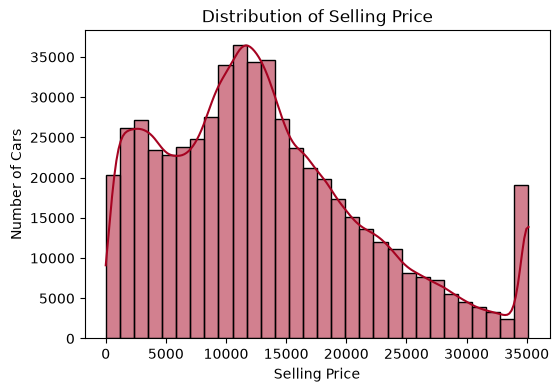

In [60]:
plt.figure(figsize=(6,4))

sns.histplot(
    clean_df['SellingPrice'],
    bins=30,
    kde=True,
    color='#A60321'
)

plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')

plt.show()

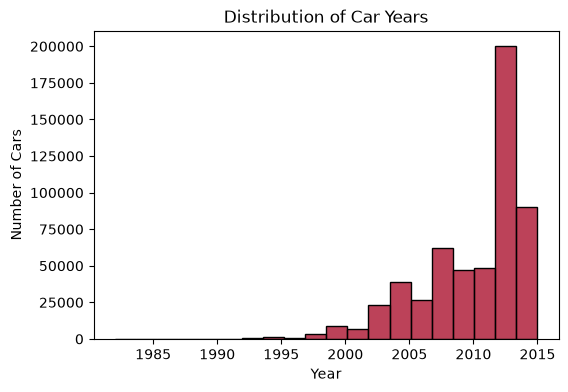

In [61]:
plt.figure(figsize=(6,4))

sns.histplot(
    clean_df['Year'],
    bins=20,
    color='#A60321'
)

plt.title('Distribution of Car Years')
plt.xlabel('Year')
plt.ylabel('Number of Cars')

plt.show()

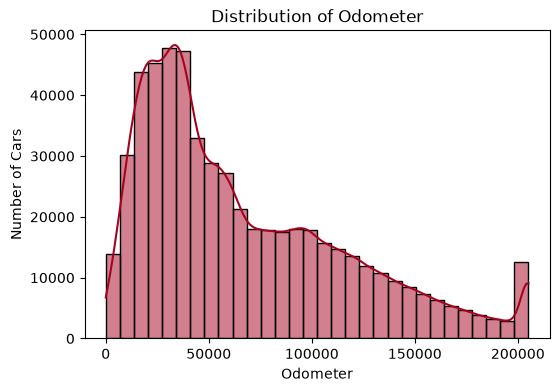

In [62]:
plt.figure(figsize=(6,4))

sns.histplot(
    clean_df['Odometer'],
    bins=30,
    kde=True,
    color='#A60321'
)

plt.title('Distribution of Odometer')
plt.xlabel('Odometer')
plt.ylabel('Number of Cars')

plt.show()

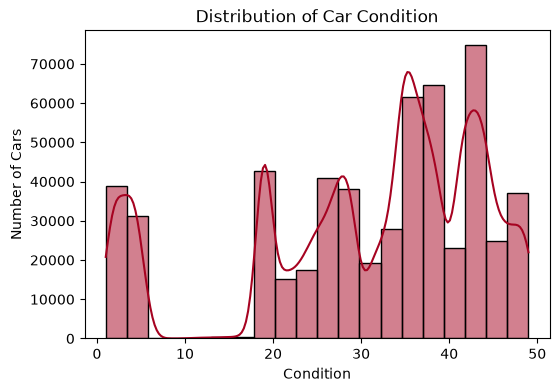

In [63]:
plt.figure(figsize=(6,4))

sns.histplot(
    clean_df['ConditionValue'],
    bins=20,
    kde=True,
    color='#A60321'
)

plt.title('Distribution of Car Condition')
plt.xlabel('Condition')
plt.ylabel('Number of Cars')

plt.show()

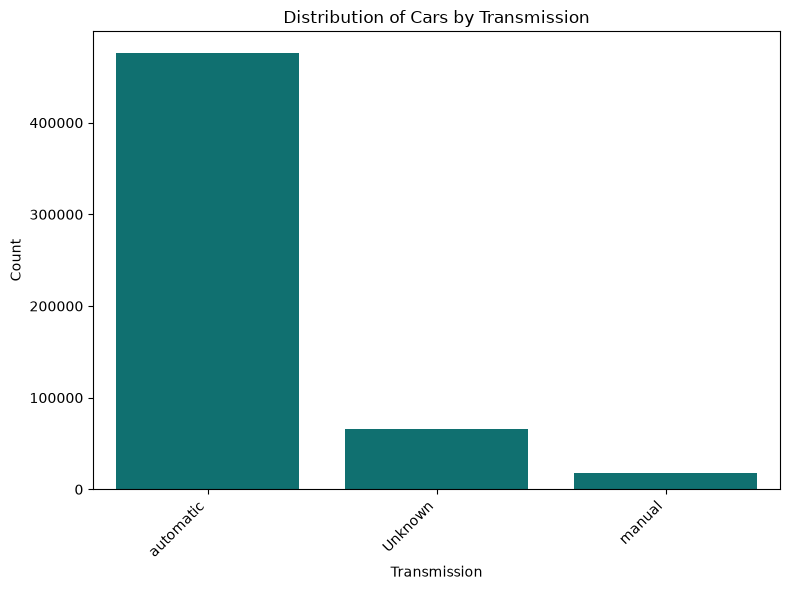

In [64]:
top_transmissions = clean_df["Transmission"].value_counts().head(20)
plt.figure(figsize=(8, 6))

sns.countplot(
    data=clean_df, 
    x="Transmission", 
    color="teal",
    order=top_transmissions.index
)

plt.xticks(rotation=45, ha='right')
plt.xlabel("Transmission")
plt.ylabel("Count")
plt.title("Distribution of Cars by Transmission")
plt.tight_layout()

plt.show()

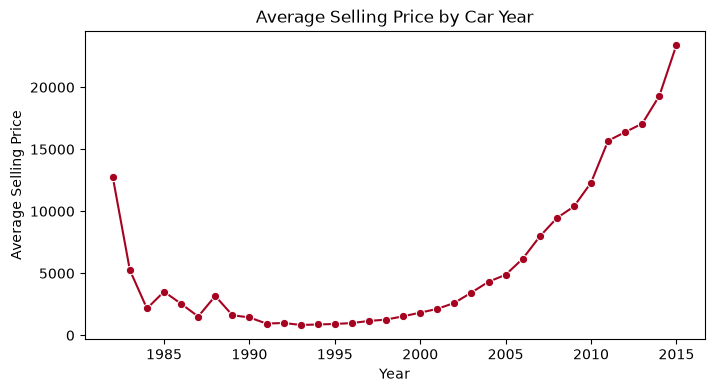

In [65]:
plt.figure(figsize=(8,4))

sns.lineplot(
    data=clean_df.groupby("Year", as_index=False)["SellingPrice"].mean(),
    x="Year",
    y="SellingPrice",
    color="#A60321",
    marker="o"
)

plt.title("Average Selling Price by Car Year")
plt.xlabel("Year")
plt.ylabel("Average Selling Price")

plt.show()

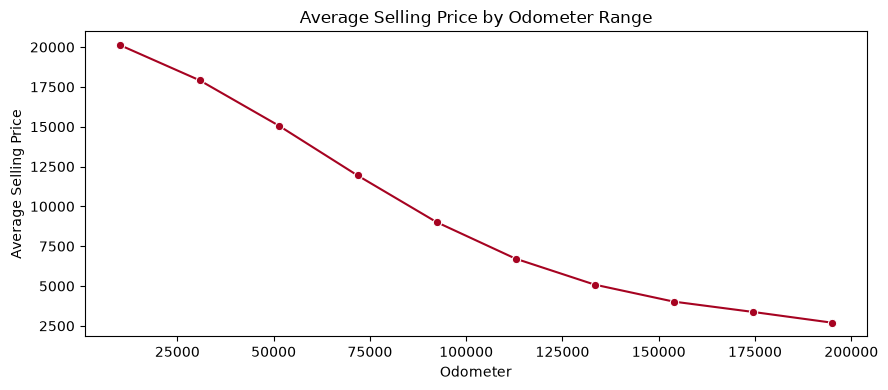

In [66]:
clean_df['OdometerGroup'] = pd.cut(
    clean_df['Odometer'],
    bins=10
)

plot_data = clean_df.groupby(
    'OdometerGroup',
    observed=True
)['SellingPrice'].mean().reset_index()

plot_data['OdometerMid'] = plot_data['OdometerGroup'].apply(
    lambda x: x.mid
)

plt.figure(figsize=(9,4))

sns.lineplot(
    data=plot_data,
    x='OdometerMid',
    y='SellingPrice',
    color='#A60321',
    marker='o'
)

plt.title('Average Selling Price by Odometer Range')
plt.xlabel('Odometer')
plt.ylabel('Average Selling Price')

plt.tight_layout()
plt.show()

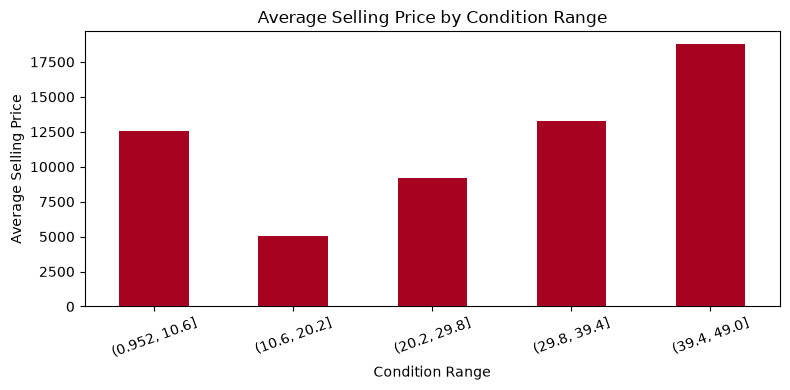

In [67]:
clean_df['ConditionGroup'] = pd.cut(
    clean_df['ConditionValue'],
    bins=5
)

plt.figure(figsize=(8,4))

clean_df.groupby('ConditionGroup', observed=True)['SellingPrice'].mean().plot(
    kind='bar',
    color='#A60321'
)

plt.title('Average Selling Price by Condition Range')
plt.xlabel('Condition Range')
plt.ylabel('Average Selling Price')

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

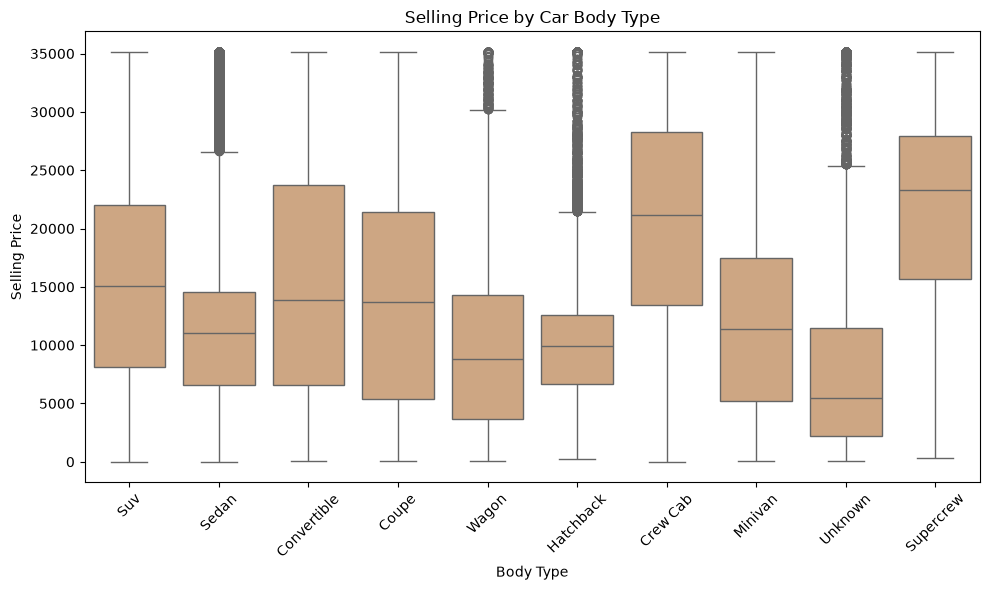

In [68]:
plt.figure(figsize=(10, 6))

top_bodies = clean_df['Body'].value_counts().head(10).index

sns.boxplot(
    data=clean_df[clean_df['Body'].isin(top_bodies)],
    x='Body',
    y='SellingPrice',
    color='#D9A577'
)

plt.title('Selling Price by Car Body Type')
plt.xlabel('Body Type')
plt.ylabel('Selling Price')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

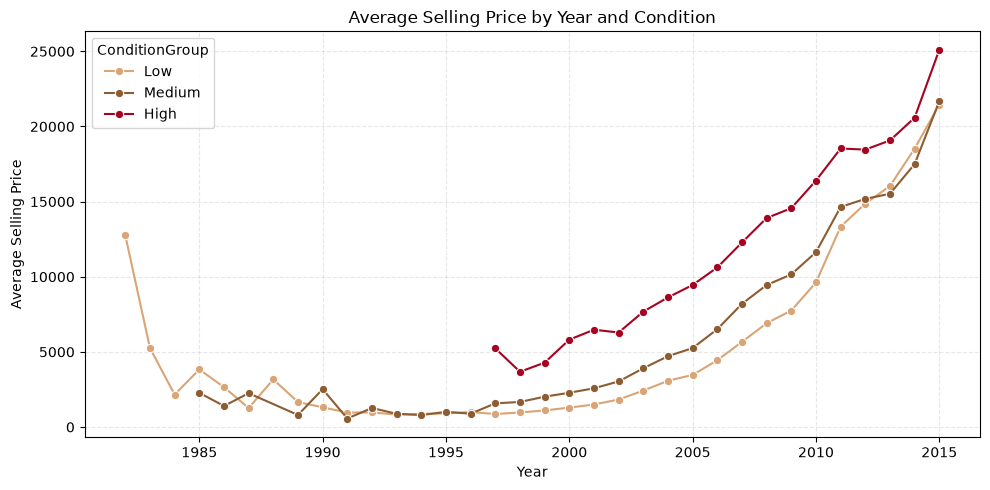

In [69]:
clean_df['ConditionGroup'] = pd.cut(
    clean_df['ConditionValue'],
    bins=[0, 20, 40, 50],
    labels=['Low', 'Medium', 'High']
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=clean_df.groupby(
        ['Year', 'ConditionGroup'],
        observed=True
    )['SellingPrice'].mean().reset_index(),
    x='Year',
    y='SellingPrice',
    hue='ConditionGroup',
    marker='o',
    palette=['#D9A577', '#8C5C32', '#A60321']
)

plt.title('Average Selling Price by Year and Condition')
plt.xlabel('Year')
plt.ylabel('Average Selling Price')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [72]:
clean_df.to_csv("VehicleSales_Clean.csv", index=False)